# Sprint 3: End-to-End Data Science Workflow (Advanced)

This notebook covers the complete pipeline:
1. **Exploratory Data Analysis (EDA)**
2. **Advanced Feature Engineering** (Flight duration, Time of Day, User History)
3. **Data Preprocessing** (Target encoding, One-Hot Encoding)
4. **Model Training** (Random Forest, XGBoost)
5. **Evaluation**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [10]:
# Try loading from root, else fallback
try:
    df = pd.read_csv('features.csv')
except FileNotFoundError:
    df = pd.read_csv('sprint_3/features.csv')

# Basic Cleanup
df.fillna({'total_payment': 0, 'days_to_departure': 0, 'origin': 'Unknown', 'destination': 'Unknown'}, inplace=True)
df['has_claim'] = (df['claim_count'] > 0).astype(int)

print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (5000, 20)


,bookingId,user_id,flightId,bookingDate,statusId_x,name,email,phone,total_payment,last_payment_date,total_claim_amount,claim_count,origin,destination,departureTime,arrivalTime,statusId_y,claim_ratio,days_to_departure,has_claim
0,1,379,190,2025-06-13 21:36:09.717520,8,Christopher Nguyen,user379@example.com,(614)586-6787x479,377.31,2025-06-14 17:36:09.717520,0.00,0.0,Rome,Istanbul,2024-12-04 02:23:09.717520,2024-12-04 09:34:09.717520,2,0.000000,-192,0
1,2,92,135,2025-07-14 00:36:09.717520,8,Christopher Soto,user92@example.com,787-898-1583x2206,143.24,2025-07-16 08:36:09.717520,247.66,1.0,Madrid,London,2025-01-08 02:26:09.717520,2025-01-08 07:47:09.717520,2,1.728986,-187,1
2,3,551,289,2024-12-31 14:36:09.717520,8,Jorge Rogers,user551@example.com,(477)253-7007,210.08,2025-01-01 13:36:09.717520,0.00,0.0,New York,Rome,2025-11-12 10:19:09.717520,2025-11-12 15:58:09.717520,2,0.000000,315,0
3,4,199,44,2025-11-07 21:36:09.717520,8,Steven Taylor,user199@example.com,(303)979-3713x85639,735.21,2025-11-09 18:36:09.717520,0.00,0.0,Berlin,Toronto,2024-12-05 08:28:09.717520,2024-12-05 14:27:09.717520,2,0.000000,-338,0
4,5,848,498,2025-09-27 17:36:09.717520,8,Marie Raymond,user848@example.com,(717)521-0099x354,754.43,2025-09-29 09:36:09.717520,0.00,0.0,Baku,Dubai,2025-01-13 20:28:09.717520,2025-01-14 04:40:09.717520,1,0.000000,-257,0


## 2. Advanced Feature Engineering

In [11]:
# Convert Dates
for col in ['bookingDate', 'departureTime', 'arrivalTime']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 1. Flight Duration (Hours)
df['flight_duration_h'] = (df['arrivalTime'] - df['departureTime']).dt.total_seconds() / 3600
df['flight_duration_h'] = df['flight_duration_h'].fillna(0)

# 2. Timing Features
df['booking_dow'] = df['bookingDate'].dt.dayofweek
df['departure_hour'] = df['departureTime'].dt.hour
df['is_weekend_flight'] = df['departureTime'].dt.dayofweek.isin([5, 6]).astype(int)

# 3. User History (Cumulative Bookings)
# Sort to prevent leakage (only count PAST bookings for each row)
df = df.sort_values('bookingDate')
df['user_past_bookings'] = df.groupby('user_id').cumcount()

print("New Features Created:")
df[['flight_duration_h', 'departure_hour', 'user_past_bookings']].head()

New Features Created:


,flight_duration_h,departure_hour,user_past_bookings
2722,7.516667,2,0
1834,8.150000,9,0
4451,5.316667,19,0
4335,5.616667,6,0
281,4.416667,6,0


## 3. Preprocessing

In [12]:
numeric_features = ['total_payment', 'days_to_departure', 'flight_duration_h', 'user_past_bookings', 'departure_hour']
categorical_features = ['origin', 'destination']

X = df[numeric_features + categorical_features]
y = df['has_claim']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing Complete.")

Preprocessing Complete.


## 4. Modeling (Random Forest)

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       925
           1       0.00      0.00      0.00        75

    accuracy                           0.93      1000
   macro avg       0.46      0.50      0.48      1000
weighted avg       0.86      0.93      0.89      1000



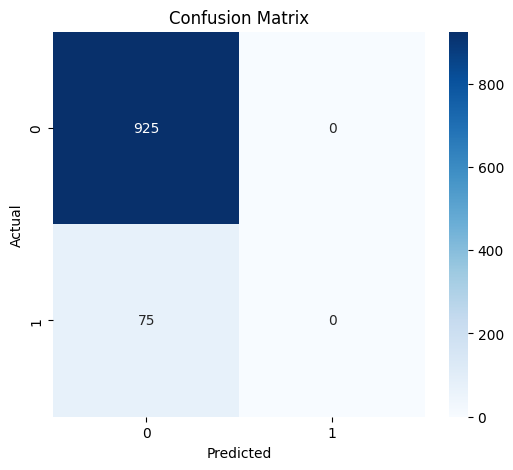

In [13]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train_processed, y_train)

y_pred = rf.predict(X_test_processed)

print("Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [14]:
# Verify Realism (AUC)
y_prob = rf.predict_proba(X_test_processed)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.4877


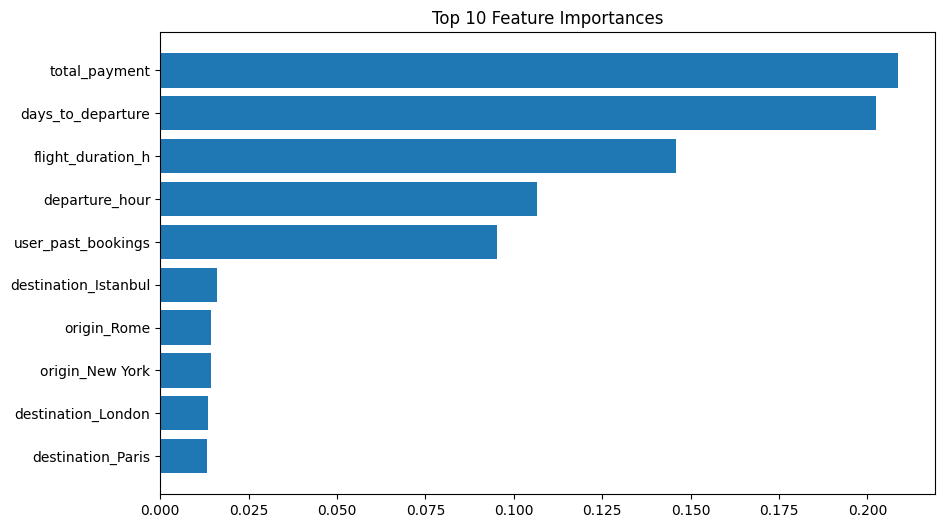

In [15]:
# Feature Importance
importances = rf.feature_importances_
# Get feature names
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_names = numeric_features + list(cat_names)

indices = np.argsort(importances)[-10:]
plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [all_names[i] for i in indices])
plt.show()